# Big Belly Forecasting - Bin Fullness Forecasting

Full pipeline: loads raw CLEAN data, runs fill-rate model and rolling forecast, displays all results inline.

**Run all cells top to bottom. Files needed in the same directory:**
- `Daily Collection Activity - CLEAN 2024 (1).csv`
- `Daily Collection Activity - CLEAN 2025 (1).csv`
- `Daily Collection Activity - CLEAN 2026 (1).csv`
- `bin_fill_curve_coefficients.csv`


## 1. Setup

In [3]:
import pandas as pd
import numpy as np
import warnings
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

warnings.filterwarnings('ignore')

files = [
    'Daily Collection Activity - CLEAN 2024 (1).csv',
    'Daily Collection Activity - CLEAN 2025 (1).csv',
    'Daily Collection Activity - CLEAN 2026 (1).csv',
]
COEFFS_PATH    = 'bin_fill_curve_coefficients.csv'
QUANTILES_PATH = 'bin_quantile_forecasts.csv'  # produced by modeling notebook

THRESHOLD          = 60.0
ONCE_A_WEEK_CUTOFF = 84      # hours; >84h to reach 60% = once-a-week
MAX_HOURS          = 336.0   # cap; anything beyond 2 weeks treated as rarely_full

STREAM_MAP = {
    'Waste':        'Landfill',
    'Compostables': 'Compostables',
    'Bottles/Cans': 'Recyclables',
}
STREAM_COLORS = {
    'Landfill':     '#e74c3c',
    'Compostables': '#27ae60',
    'Recyclables':  '#2980b9',
}


## 2. Load and Clean CLEAN Export Data

In [4]:
def load_clean_csv(path):
    # CLEAN exports have a 10-row metadata header before column names
    df = pd.read_csv(path, skiprows=10)
    df.columns = df.columns.str.strip()
    return df

raw_frames = []
for f in files:
    try:
        raw_frames.append(load_clean_csv(f))
        print(f"Loaded: {f}  ({len(raw_frames[-1]):,} rows)")
    except FileNotFoundError:
        print(f"NOT FOUND: {f}")

log = pd.concat(raw_frames, ignore_index=True)

log = log.rename(columns={
    'Serial':                       'serial',
    'Description':                  'location',
    'Capacity':                     'capacity',
    'Stream Type':                  'stream_type_raw',
    'Reason':                       'collection_reason',
    'Fullness Level at Collection': 'fullness_raw',
    'Collection Time':              'timestamp',
    'Note':                         'note',
})

log['timestamp'] = pd.to_datetime(log['timestamp'], errors='coerce')

log['fullness_pct'] = (
    log['fullness_raw'].astype(str).str.strip()
    .str.replace('%', '', regex=False)
    .str.replace(r' .*', '', regex=True)
    .pipe(pd.to_numeric, errors='coerce')
)

log['stream_type'] = log['stream_type_raw'].map(STREAM_MAP).fillna(log['stream_type_raw'])

log = log.dropna(subset=['serial', 'timestamp', 'fullness_pct'])
log = log[log['stream_type'].isin(['Landfill', 'Compostables', 'Recyclables'])]
log['serial'] = log['serial'].astype(int)
log = log[log['timestamp'].dt.year >= 2023]
log = log.sort_values(['serial', 'timestamp']).reset_index(drop=True)

print(f"\nCombined dataset: {len(log):,} events")
print(f"Unique bins:       {log['serial'].nunique()}")
print(f"Date range:        {log['timestamp'].min().date()} to {log['timestamp'].max().date()}")
print(f"\nStream distribution:")
print(log['stream_type'].value_counts().to_string())
print(f"\nCollection reason distribution:")
print(log['collection_reason'].value_counts().to_string())


Loaded: Daily Collection Activity - CLEAN 2024 (1).csv  (14,568 rows)
Loaded: Daily Collection Activity - CLEAN 2025 (1).csv  (18,097 rows)
Loaded: Daily Collection Activity - CLEAN 2026 (1).csv  (27,279 rows)

Combined dataset: 59,111 events
Unique bins:       248
Date range:        2023-01-03 to 2026-02-20

Stream distribution:
stream_type
Landfill        25379
Compostables    20204
Recyclables     13528

Collection reason distribution:
collection_reason
Fullness     31888
Not Ready    20742
Age           6481


## 3. Key EDA Findings

In [5]:
needed     = log[log['collection_reason'].isin(['Fullness', 'Age'])]
not_ready  = log[log['collection_reason'] == 'Not Ready']
wasted_pct = len(not_ready) / len(log) * 100

print(f"Total collections:            {len(log):,}")
print(f"Needed collections:           {len(needed):,}  ({len(needed)/len(log)*100:.1f}%)")
print(f"Wasted trips (Not Ready):     {len(not_ready):,}  ({wasted_pct:.1f}%)")
print(f"Avg fullness at collection:   {log['fullness_pct'].mean():.1f}%")
print(f"Avg fullness — needed only:   {needed['fullness_pct'].mean():.1f}%")
print(f"Avg fullness — wasted trips:  {not_ready['fullness_pct'].mean():.1f}%")


Total collections:            59,111
Needed collections:           38,369  (64.9%)
Wasted trips (Not Ready):     20,742  (35.1%)
Avg fullness at collection:   47.1%
Avg fullness — needed only:   63.0%
Avg fullness — wasted trips:  17.7%


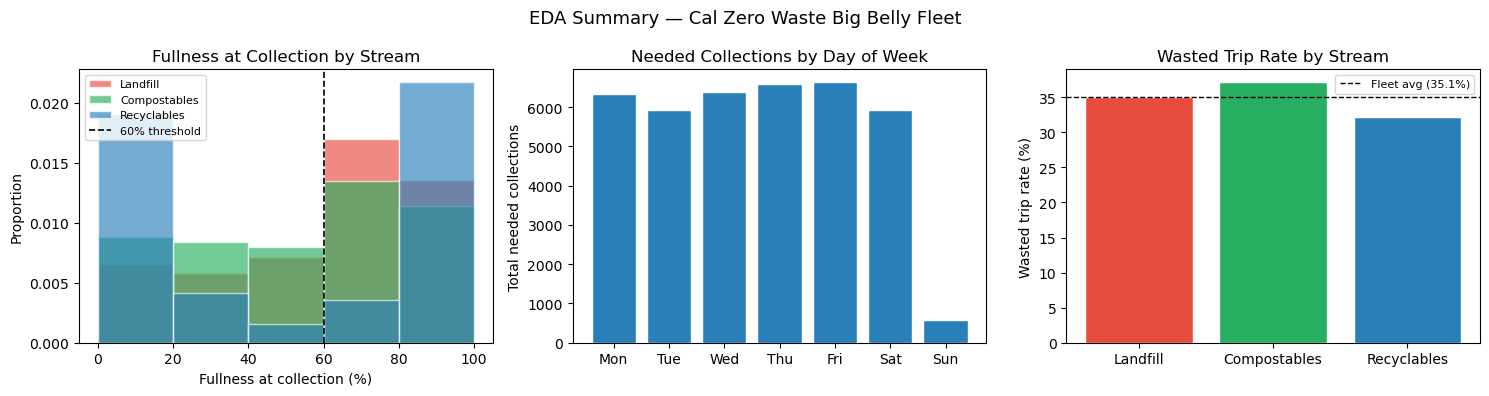

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
for stream, color in STREAM_COLORS.items():
    data = log[log['stream_type'] == stream]['fullness_pct']
    ax.hist(data, bins=[0, 20, 40, 60, 80, 100], alpha=0.65,
            color=color, label=stream, edgecolor='white', density=True)
ax.axvline(THRESHOLD, color='black', linestyle='--', linewidth=1.2, label='60% threshold')
ax.set_xlabel('Fullness at collection (%)')
ax.set_ylabel('Proportion')
ax.set_title('Fullness at Collection by Stream')
ax.legend(fontsize=8)

ax = axes[1]
dow_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
dow_counts = needed.groupby(needed['timestamp'].dt.dayofweek).size()
ax.bar(dow_labels, [dow_counts.get(i, 0) for i in range(7)],
       color='#2980b9', edgecolor='white')
ax.set_ylabel('Total needed collections')
ax.set_title('Needed Collections by Day of Week')

ax = axes[2]
wasted_by_stream = (
    log.groupby('stream_type')
    .apply(lambda x: (x['collection_reason'] == 'Not Ready').sum() / len(x) * 100)
    .reindex(['Landfill', 'Compostables', 'Recyclables'])
)
ax.bar(wasted_by_stream.index,
       wasted_by_stream.values,
       color=[STREAM_COLORS[s] for s in wasted_by_stream.index],
       edgecolor='white')
ax.axhline(wasted_pct, color='black', linestyle='--', linewidth=1,
           label=f'Fleet avg ({wasted_pct:.1f}%)')
ax.set_ylabel('Wasted trip rate (%)')
ax.set_title('Wasted Trip Rate by Stream')
ax.legend(fontsize=8)

plt.suptitle('EDA Summary — Cal Zero Waste Big Belly Fleet', fontsize=13)
plt.tight_layout()
plt.show()


## 4. Fill-Rate Model — Time-to-Full and Frequency Classification

In [7]:
coeffs = pd.read_csv(COEFFS_PATH)
coeffs['stream_type'] = coeffs['stream_type'].map(STREAM_MAP).fillna(coeffs['stream_type'])

stream_medians = (
    coeffs[coeffs['best_curve'] != 'insufficient_data']
    .groupby('stream_type')['median_elapsed_hours']
    .median()
)

def predict_fill(row, t):
    t = np.asarray(t, dtype=float)
    curve = row['best_curve']
    if curve == 'sigmoid':
        L, k, t0 = row['coeff_L'], row['coeff_k'], row['coeff_t0']
        # Clip exponent to prevent overflow
        exp_arg = np.clip(-k * (t - t0), -500, 500)
        fill = L / (1 + np.exp(exp_arg))
    elif curve == 'saturating':
        a, b = row['coeff_a'], row['coeff_b']
        fill = a * (1 - np.exp(np.clip(-b * t, -500, 500)))
    elif curve == 'power_law':
        a, b = row['coeff_a'], row['coeff_b']
        fill = np.where(t > 0, a * np.power(np.maximum(t, 1e-9), b), 0.0)
    elif curve == 'logarithmic':
        a, b = row['coeff_a'], row['coeff_b']
        fill = a * np.log(np.maximum(t, 1e-6)) + b
    elif curve == 'linear':
        fill = row['coeff_a'] * t
    else:
        fill = np.full_like(t, np.nan)
    return np.clip(fill, 0, 100)

def hours_to_full(row, threshold=THRESHOLD):
    curve = row['best_curve']
    try:
        if curve == 'sigmoid':
            L, k, t0 = row['coeff_L'], row['coeff_k'], row['coeff_t0']
            if L <= threshold: return np.inf, 'rarely_full'
            t = t0 - np.log(L / threshold - 1) / k
            return float(np.clip(max(t, 0), 0, MAX_HOURS * 100)), 'solved'
        elif curve == 'saturating':
            a, b = row['coeff_a'], row['coeff_b']
            if a <= threshold: return np.inf, 'rarely_full'
            t = -np.log(1 - threshold / a) / b
            return float(np.clip(max(t, 0), 0, MAX_HOURS * 100)), 'solved'
        elif curve == 'power_law':
            a, b = row['coeff_a'], row['coeff_b']
            if a <= 0 or b <= 0: return np.nan, 'fallback'
            return float(np.clip((threshold / a) ** (1 / b), 0, MAX_HOURS * 100)), 'solved'
        elif curve == 'logarithmic':
            a, b = row['coeff_a'], row['coeff_b']
            if a <= 0: return np.nan, 'fallback'
            t = np.exp((threshold - b) / a)
            # Logarithmic can produce astronomically large values — cap aggressively
            return float(np.clip(t, 0, MAX_HOURS * 100)), 'solved'
        elif curve == 'linear':
            a = row['coeff_a']
            if a <= 0: return np.nan, 'fallback'
            return float(np.clip(threshold / a, 0, MAX_HOURS * 100)), 'solved'
        else:
            return float(stream_medians.get(row['stream_type'], 72)), 'fallback'
    except Exception:
        return float(stream_medians.get(row['stream_type'], 72)), 'fallback'

res = coeffs.apply(
    lambda r: pd.Series(hours_to_full(r), index=['hours_to_full', 'ttf_status']), axis=1
)
coeffs[['hours_to_full', 'ttf_status']] = res

# Cap: anything beyond MAX_HOURS is treated as rarely_full
coeffs.loc[coeffs['hours_to_full'] > MAX_HOURS, 'ttf_status'] = 'rarely_full'
coeffs.loc[coeffs['hours_to_full'] > MAX_HOURS, 'hours_to_full'] = np.inf

def classify_frequency(row):
    if row['ttf_status'] == 'rarely_full' or not np.isfinite(row['hours_to_full']):
        return 'rarely_full'
    elif row['hours_to_full'] <= ONCE_A_WEEK_CUTOFF:
        return 'multi_visit'
    else:
        return 'once_a_week'

coeffs['frequency_class'] = coeffs.apply(classify_frequency, axis=1)

print("Frequency class by stream type:")
print(coeffs.groupby(['stream_type', 'frequency_class']).size().unstack(fill_value=0).to_string())
print(f"\nOverall: {(coeffs['frequency_class']=='multi_visit').sum()} multi-visit | "
      f"{(coeffs['frequency_class']=='once_a_week').sum()} once-a-week | "
      f"{(coeffs['frequency_class']=='rarely_full').sum()} rarely-full")

# ── Load LightGBM quantile outputs (P10/P50/P90 per bin) ─────────────────────
try:
    bin_q = pd.read_csv(QUANTILES_PATH)
    print(f"Quantile forecasts loaded: {len(bin_q)} bins")
except FileNotFoundError:
    bin_q = None
    print("WARNING: bin_quantile_forecasts.csv not found.")
    print("Run the modeling notebook first to generate it.")
    print("Falling back to fill-curve point estimates only.")


Frequency class by stream type:
frequency_class  multi_visit  once_a_week  rarely_full
stream_type                                           
Compostables              24           24           27
Landfill                  39           15           20
Recyclables               20           29           26

Overall: 83 multi-visit | 68 once-a-week | 73 rarely-full
Quantile forecasts loaded: 210 bins


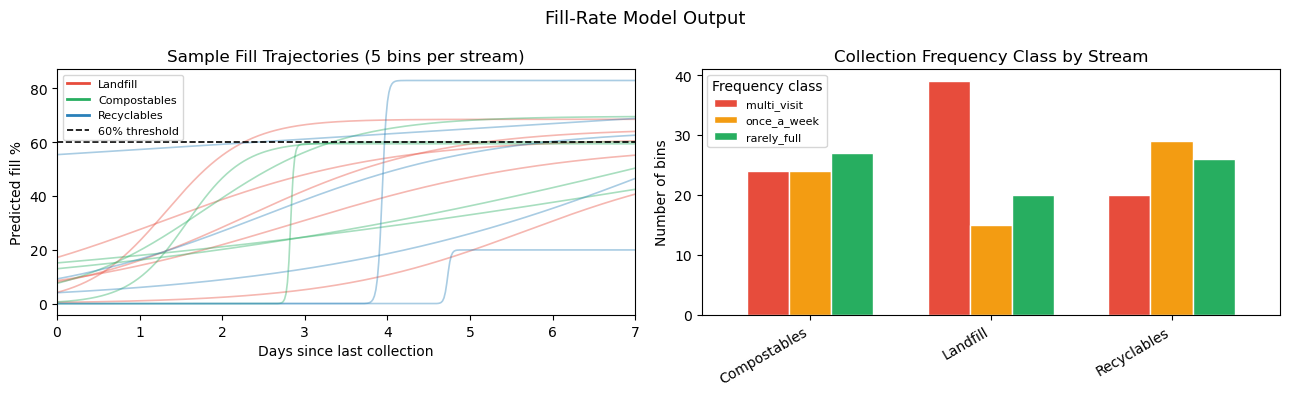

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Fill trajectories sample
ax = axes[0]
t_range = np.linspace(0, 168, 400)
for stream, color in STREAM_COLORS.items():
    sample = coeffs[
        (coeffs['stream_type'] == stream) &
        (coeffs['best_curve'].isin(['sigmoid', 'saturating', 'power_law', 'logarithmic', 'linear']))
    ].head(5)
    for _, row in sample.iterrows():
        ax.plot(t_range / 24, predict_fill(row, t_range),
                alpha=0.4, color=color, linewidth=1.2)
    if len(sample) > 0:
        ax.plot([], [], color=color, linewidth=2, label=stream)
ax.axhline(THRESHOLD, color='black', linestyle='--', linewidth=1.2, label='60% threshold')
ax.set_xlabel('Days since last collection')
ax.set_ylabel('Predicted fill %')
ax.set_title('Sample Fill Trajectories (5 bins per stream)')
ax.set_xlim(0, 7)
ax.legend(fontsize=8)

# Frequency class breakdown
ax = axes[1]
freq_colors = {'multi_visit': '#e74c3c', 'once_a_week': '#f39c12', 'rarely_full': '#27ae60'}
pivot_freq = (
    coeffs.groupby(['stream_type', 'frequency_class']).size()
    .unstack(fill_value=0)
)
pivot_freq.plot(
    kind='bar', ax=ax,
    color=[freq_colors.get(c, 'gray') for c in pivot_freq.columns],
    edgecolor='white', width=0.7
)
ax.set_title('Collection Frequency Class by Stream')
ax.set_xlabel('')
ax.set_ylabel('Number of bins')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.legend(title='Frequency class', fontsize=8)

plt.suptitle('Fill-Rate Model Output', fontsize=13)
plt.tight_layout()
plt.show()


## 5. Rolling Weekly Forecast

For each bin, uses the most recent collection event as the reset point and projects
when it will next reach the 60% threshold. Urgency bands provide a coarse operational
signal consistent with the CLEAN dashboard's existing red/green workflow.


In [9]:
NOW = log['timestamp'].max()  # use latest timestamp in the data, not wall clock

last_events = (
    log.sort_values('timestamp')
    .groupby('serial').last().reset_index()
    [['serial', 'location', 'stream_type', 'timestamp', 'fullness_pct']]
    .rename(columns={'timestamp': 'last_collection_dt', 'fullness_pct': 'last_fullness'})
)

last_events = last_events.merge(
    coeffs[['serial', 'hours_to_full', 'ttf_status', 'frequency_class',
            'best_curve', 'best_r2',
            'coeff_L', 'coeff_k', 'coeff_t0', 'coeff_a', 'coeff_b']],
    on='serial', how='left'
)

# ── Merge LightGBM P10/P50/P90 if available ─────────────────────────────────
if bin_q is not None:
    last_events = last_events.merge(
        bin_q[['serial', 'p10_days', 'p50_days', 'p90_days']],
        on='serial', how='left'
    )
else:
    last_events['p10_days'] = np.nan
    last_events['p50_days'] = np.nan
    last_events['p90_days'] = np.nan

last_events['hours_elapsed'] = (
    (NOW - last_events['last_collection_dt']).dt.total_seconds() / 3600
).clip(lower=0)

last_events['current_fill_pct'] = last_events.apply(
    lambda row: round(float(predict_fill(row, row['hours_elapsed'])), 1), axis=1
)

last_events['hours_remaining'] = (
    last_events['hours_to_full'] - last_events['hours_elapsed']
).clip(lower=0)

# Safe timedelta: cap hours at MAX_HOURS before converting to avoid OverflowError
safe_hours = last_events['hours_to_full'].apply(
    lambda h: h if (np.isfinite(h) and h <= MAX_HOURS) else np.nan
)
last_events['projected_full_dt'] = last_events['last_collection_dt'] + pd.to_timedelta(
    safe_hours.fillna(0), unit='h'
)
last_events.loc[safe_hours.isna(), 'projected_full_dt'] = pd.NaT

last_events['days_until_full'] = (last_events['hours_remaining'] / 24).round(1)
last_events.loc[~last_events['hours_to_full'].apply(np.isfinite), 'days_until_full'] = np.nan

def urgency_band(row):
    if row['current_fill_pct'] >= THRESHOLD:
        return 'OVERDUE'
    elif pd.isna(row['days_until_full']) or row['ttf_status'] == 'rarely_full':
        return 'MONITOR'
    # Use P10 (optimistic/fast-fill estimate) for HIGH flag if available —
    # catches bins that could fill sooner than the curve predicts
    p10 = row['p10_days'] if pd.notna(row['p10_days']) else row['days_until_full']
    if p10 <= 1:
        return 'HIGH'
    elif row['days_until_full'] <= 3:
        return 'ELEVATED'
    elif row['days_until_full'] <= 5:
        return 'MODERATE'
    else:
        return 'LOW'

last_events['urgency_band'] = last_events.apply(urgency_band, axis=1)

urgency_order = {'OVERDUE': 0, 'HIGH': 1, 'ELEVATED': 2, 'MODERATE': 3, 'LOW': 4, 'MONITOR': 5}
last_events['_rank'] = last_events['urgency_band'].map(urgency_order)
last_events = last_events.sort_values('_rank').drop(columns='_rank')

print(f"Forecast as of: {NOW.strftime('%Y-%m-%d %H:%M')}")
print(f"\nUrgency distribution:")
print(
    last_events['urgency_band']
    .value_counts()
    .reindex(['OVERDUE', 'HIGH', 'ELEVATED', 'MODERATE', 'LOW', 'MONITOR'])
    .to_string()
)


Forecast as of: 2026-02-20 20:36

Urgency distribution:
urgency_band
OVERDUE     53
HIGH        27
ELEVATED    47
MODERATE    15
LOW         10
MONITOR     96


In [10]:
out_cols = [
    'serial', 'location', 'stream_type',
    'last_collection_dt', 'last_fullness',
    'current_fill_pct',
    'p10_days', 'days_until_full', 'p90_days',   # P10 / P50(curve) / P90
    'projected_full_dt', 'urgency_band', 'frequency_class',
    'best_curve', 'best_r2', 'ttf_status',
]
# Keep only columns that exist (p10/p90 absent if modeling notebook not run)
out_cols = [c for c in out_cols if c in last_events.columns]
forecast_table = last_events[out_cols].copy()
forecast_table['last_collection_dt'] = forecast_table['last_collection_dt'].dt.strftime('%Y-%m-%d %H:%M')
forecast_table['projected_full_dt']  = forecast_table['projected_full_dt'].dt.strftime('%Y-%m-%d %H:%M')

print(f"Forecast table: {len(forecast_table)} bins")
print()
print("Top 20 most urgent bins:")
display(forecast_table.head(20))


Forecast table: 248 bins

Top 20 most urgent bins:


,serial,location,stream_type,last_collection_dt,last_fullness,current_fill_pct,p10_days,days_until_full,p90_days,projected_full_dt,urgency_band,frequency_class,best_curve,best_r2,ttf_status
0,1503614,W08 University Drive,Compostables,2026-02-14 07:10,80.0,69.3,1.3,0.0,5.2,2026-02-17 15:08,OVERDUE,multi_visit,sigmoid,0.3614,solved
2,1503621,E19 South Path Drive,Landfill,2026-02-15 11:48,60.0,60.7,3.1,0.0,6.8,2026-02-20 15:58,OVERDUE,once_a_week,sigmoid,0.2224,solved
14,1503639,E22 May Morrison Hall,Recyclables,2026-02-15 07:44,100.0,66.0,4.1,0.0,10.9,2026-02-17 17:54,OVERDUE,multi_visit,sigmoid,0.0138,solved
11,1503636,E28 Library/Campanile Way,Compostables,2025-07-18 09:55,20.0,100.0,2.6,0.0,9.4,2025-07-26 16:30,OVERDUE,once_a_week,sigmoid,0.1236,solved
12,1503637,E22 May Morrison Hall,Compostables,2026-02-15 10:28,20.0,60.1,2.3,0.0,6.2,2026-02-19 10:11,OVERDUE,once_a_week,sigmoid,0.4425,solved
13,1503638,W08 University Drive,Recyclables,2026-02-14 08:36,80.0,61.6,4.5,0.0,9.9,2026-02-20 06:48,OVERDUE,once_a_week,sigmoid,0.1818,solved
24,1514001,U16 Durant Hall,Compostables,2026-02-13 05:56,60.0,68.8,2.9,0.0,7.7,2026-02-19 05:40,OVERDUE,once_a_week,saturating,0.4316,solved
17,1503642,E14 Physics,Recyclables,2026-02-14 07:57,60.0,82.9,6.2,0.0,11.5,2026-02-18 07:04,OVERDUE,once_a_week,sigmoid,0.9695,solved
26,1514003,W11 Moffitt Library @ Press,Compostables,2026-02-13 06:51,60.0,72.5,1.1,0.0,4.3,2026-02-16 15:21,OVERDUE,multi_visit,sigmoid,0.0533,solved
44,1514021,001 Berkeley Way (Offsite),Recyclables,2026-02-11 06:54,80.0,68.2,3.0,0.0,15.6,2026-02-17 22:10,OVERDUE,once_a_week,sigmoid,0.0173,solved


## 6. Summary Visualizations

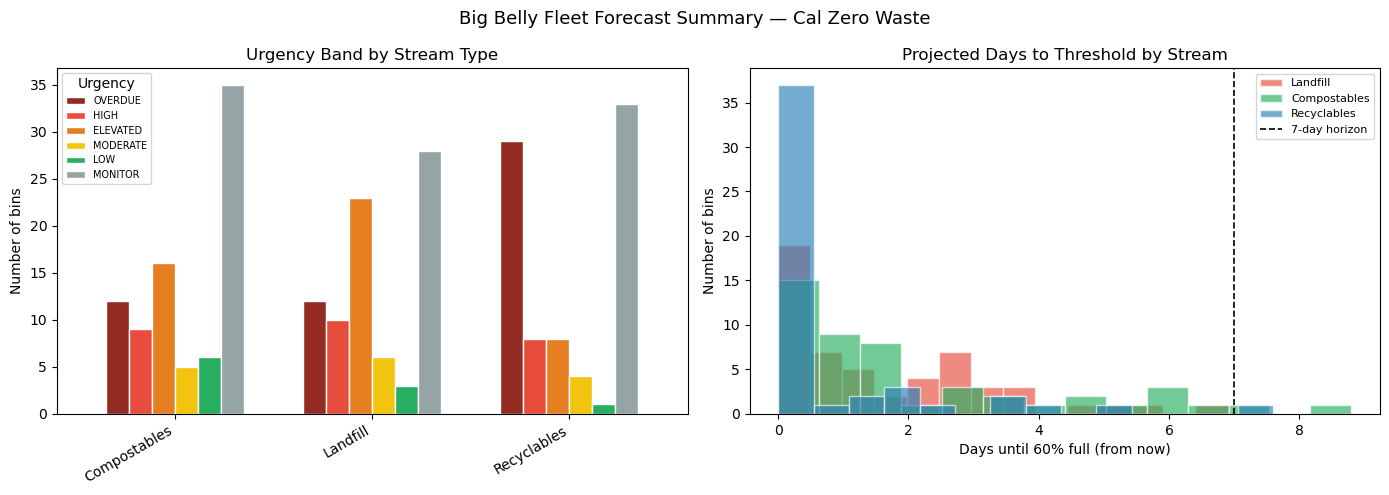

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

urgency_colors = {
    'OVERDUE':  '#922b21',
    'HIGH':     '#e74c3c',
    'ELEVATED': '#e67e22',
    'MODERATE': '#f1c40f',
    'LOW':      '#27ae60',
    'MONITOR':  '#95a5a6',
}

# Urgency band by stream
ax = axes[0]
pivot_urgency = (
    last_events.groupby(['stream_type', 'urgency_band']).size()
    .unstack(fill_value=0)
    .reindex(columns=['OVERDUE', 'HIGH', 'ELEVATED', 'MODERATE', 'LOW', 'MONITOR'], fill_value=0)
)
pivot_urgency.plot(
    kind='bar', ax=ax,
    color=[urgency_colors[c] for c in pivot_urgency.columns],
    edgecolor='white', width=0.7
)
ax.set_title('Urgency Band by Stream Type')
ax.set_xlabel('')
ax.set_ylabel('Number of bins')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.legend(title='Urgency', fontsize=7)

# Days until full distribution
ax = axes[1]
for stream, color in STREAM_COLORS.items():
    data = last_events[
        (last_events['stream_type'] == stream) &
        last_events['days_until_full'].notna() &
        (last_events['ttf_status'] != 'rarely_full')
    ]['days_until_full'].clip(0, 14)
    ax.hist(data, bins=14, alpha=0.65, color=color, label=stream, edgecolor='white')
ax.axvline(7, color='black', linestyle='--', linewidth=1.2, label='7-day horizon')
ax.set_xlabel('Days until 60% full (from now)')
ax.set_ylabel('Number of bins')
ax.set_title('Projected Days to Threshold by Stream')
ax.legend(fontsize=8)

plt.suptitle('Big Belly Fleet Forecast Summary — Cal Zero Waste', fontsize=13)
plt.tight_layout()
plt.show()


## 7. Key Findings Summary

In [12]:
multi  = (last_events['frequency_class'] == 'multi_visit').sum()
once   = (last_events['frequency_class'] == 'once_a_week').sum()
rarely = (last_events['frequency_class'] == 'rarely_full').sum()
total  = len(last_events)
unmatched = total - multi - once - rarely
high_urgency = last_events['urgency_band'].isin(['OVERDUE', 'HIGH']).sum()
within_week  = last_events['urgency_band'].isin(['OVERDUE', 'HIGH', 'ELEVATED', 'MODERATE']).sum()

ttf_by_stream = (
last_events[
    (last_events['ttf_status'] != 'rarely_full') &
    (last_events['days_until_full'] > 0)
].groupby('stream_type')['days_until_full'].median()
)

print("=" * 55)
print("  KEY FINDINGS SUMMARY")
print("=" * 55)
print(f"  Fleet size (bins with forecasts):  {total}")
print()
print(f"  Wasted trip rate (full dataset):   {wasted_pct:.1f}%")
print(f"  Avg fullness at collection:        {log['fullness_pct'].mean():.1f}%")
print()
print(f"  Frequency classification:")
print(f"    Multi-visit  (fills in <=3.5d):  {multi} bins  ({multi/total*100:.0f}%)")
print(f"    Once-a-week  (fills in 3.5-7d):  {once} bins  ({once/total*100:.0f}%)")
print(f"    Rarely full  (>7d or monitor):   {rarely} bins  ({rarely/total*100:.0f}%)")
print(f"    Unmatched (not in coeffs):       {unmatched} bins  ({unmatched/total*100:.0f}%)")
print()
print(f"  Current urgency (as of {NOW.strftime('%Y-%m-%d')}):")
print(f"    Needs collection today:          {high_urgency} bins")
print(f"    Needs collection this week:      {within_week} bins")
print()
print(f"  Median days to threshold by stream:")
for stream, days in ttf_by_stream.items():
    print(f"    {stream:15s}:  {days} days")
print("=" * 55)


  KEY FINDINGS SUMMARY
  Fleet size (bins with forecasts):  248

  Wasted trip rate (full dataset):   35.1%
  Avg fullness at collection:        47.1%

  Frequency classification:
    Multi-visit  (fills in <=3.5d):  83 bins  (33%)
    Once-a-week  (fills in 3.5-7d):  68 bins  (27%)
    Rarely full  (>7d or monitor):   73 bins  (29%)
    Unmatched (not in coeffs):       24 bins  (10%)

  Current urgency (as of 2026-02-20):
    Needs collection today:          80 bins
    Needs collection this week:      142 bins

  Median days to threshold by stream:
    Compostables   :  1.8 days
    Landfill       :  2.0 days
    Recyclables    :  2.0 days


## 8. Apply Conformal Calibration and Export Operational Forecast

In [16]:
forecast_df = pd.read_csv('bin_quantile_forecasts_enriched.csv')
required_cols = [
    "serial", "p10_hours", "p50_hours", "p90_hours",
    "current_fill_pct_curve", "days_until_full_curve",
    "curve_available", "curve_asymptote",
]
missing = [c for c in required_cols if c not in forecast_df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

numeric_cols = [
    "p10_hours", "p50_hours", "p90_hours",
    "current_fill_pct_curve", "days_until_full_curve", "curve_asymptote"
]
for col in numeric_cols:
    forecast_df[col] = pd.to_numeric(forecast_df[col], errors="coerce")

def to_bool(x):
    if pd.isna(x):
        return False
    if isinstance(x, bool):
        return x
    return str(x).strip().lower() in ["true", "1", "yes", "y"]

forecast_df["curve_available"] = forecast_df["curve_available"].apply(to_bool)

QHAT_HOURS = 16.98   # from 04_calibration.ipynb
THRESHOLD  = 60.0

forecast_df["p10_hours_cal"] = (forecast_df["p10_hours"] - QHAT_HOURS).clip(lower=0)
forecast_df["p50_hours_cal"] = forecast_df["p50_hours"]
forecast_df["p90_hours_cal"] = forecast_df["p90_hours"] + QHAT_HOURS

forecast_df["p50_hours_cal"] = np.maximum(forecast_df["p50_hours_cal"], forecast_df["p10_hours_cal"])
forecast_df["p90_hours_cal"] = np.maximum(forecast_df["p90_hours_cal"], forecast_df["p50_hours_cal"])

forecast_df["p10_days_cal"] = forecast_df["p10_hours_cal"] / 24.0
forecast_df["p50_days_cal"] = forecast_df["p50_hours_cal"] / 24.0
forecast_df["p90_days_cal"] = forecast_df["p90_hours_cal"] / 24.0

def assign_urgency(row):
    current_fill    = row["current_fill_pct_curve"]
    curve_available = row["curve_available"]
    curve_asymptote = row["curve_asymptote"]
    p10_days        = row["p10_days_cal"]
    curve_days      = row["days_until_full_curve"]
    p50_days        = row["p50_days_cal"]

    if pd.notna(current_fill) and current_fill >= THRESHOLD:
        return "OVERDUE"
    if (not curve_available) or (pd.notna(curve_asymptote) and curve_asymptote < THRESHOLD):
        return "MONITOR"
    if pd.notna(p10_days) and p10_days <= 1:
        return "HIGH"
    if pd.notna(curve_days):
        if curve_days <= 3:   return "ELEVATED"
        elif curve_days <= 5: return "MODERATE"
        else:                 return "LOW"
    if pd.notna(p50_days):
        if p50_days <= 3:     return "ELEVATED"
        elif p50_days <= 5:   return "MODERATE"
        else:                 return "LOW"
    return "MONITOR"

forecast_df["urgency_label"] = forecast_df.apply(assign_urgency, axis=1)

print(forecast_df["urgency_label"].value_counts())
forecast_df.to_csv("operational_forecast_full.csv", index=False)
print("Saved: operational_forecast_full.csv")

urgency_label
MONITOR     96
OVERDUE     53
ELEVATED    42
LOW         25
HIGH        18
MODERATE    14
Name: count, dtype: int64
Saved: operational_forecast_full.csv
